In [3]:
import pandas as pd
import numpy as np 

In [12]:
train_v2 = pd.read_csv('train_v2.csv')
members_v3 = pd.read_csv('members_v3.csv')  
transactions_v2 = pd.read_csv('transactions_v2.csv')
user_v2 = pd.read_csv('user_logs_v2.csv')

#  Understanding

### train_v2


In [28]:
print(train_v2.info(), '\n')
print(train_v2.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      970960 non-null  object
 1   is_churn  970960 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 14.8+ MB
None 

msno        0
is_churn    0
dtype: int64


is_churn
0    91.005809
1     8.994191
Name: proportion, dtype: float64


C:\Users\CUONG\AppData\Local\Temp\ipykernel_14192\955210187.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_v2, x='is_churn', palette='Set2')


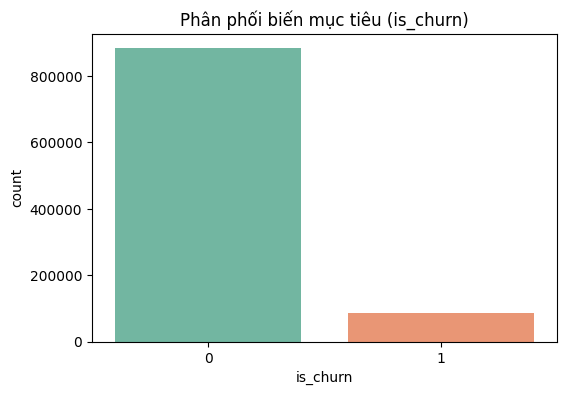

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính tỷ lệ Churn
churn_rate = train_v2['is_churn'].value_counts(normalize=True) * 100
print(churn_rate)

# Vẽ biểu đồ
plt.figure(figsize=(6, 4))
sns.countplot(data=train_v2, x='is_churn', palette='Set2')
plt.title('Phân phối biến mục tiêu (is_churn)')
plt.show()

In [43]:
train_v2.duplicated().sum()

np.int64(0)

- train_v2 không có missing - không duplicated
- 91% khách hàng ở lại, tỉ lệ rời bỏ là 9%
- Kiểu dữ liệu ổn 
+ => data sạch




- Lưu ý cho bước Model: Tuyệt đối không dùng Accuracy để đánh giá mô hình sau này (vì nếu model đoán bừa 100% người dùng đều "Ở lại", nó vẫn đạt độ chính xác 91%). Bạn sẽ phải dùng các chỉ số như F1-Score, Precision, Recall hoặc ROC-AUC.

### members_v3

In [33]:
members_v3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   msno                    object
 1   city                    int64 
 2   bd                      int64 
 3   gender                  object
 4   registered_via          int64 
 5   registration_init_time  int64 
dtypes: int64(4), object(2)
memory usage: 309.9+ MB


In [36]:
members_v3.isnull().sum()

msno                            0
city                            0
bd                              0
gender                    4429505
registered_via                  0
registration_init_time          0
dtype: int64

In [38]:
members_v3['bd'].value_counts()

bd
 0       4540215
 22       112200
 21       110574
 20       110452
 27       102769
          ...   
 167           1
-484           1
-10            1
-3152          1
 573           1
Name: count, Length: 386, dtype: int64

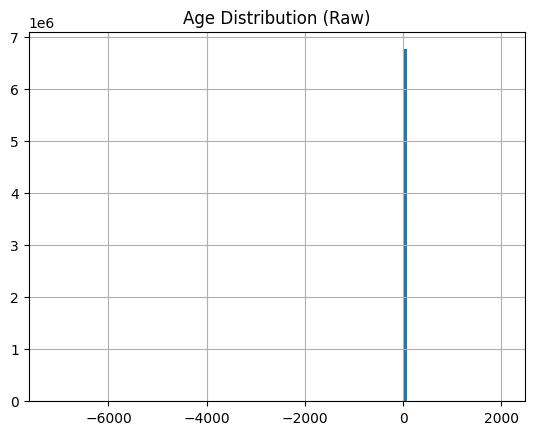

In [37]:
members_v3['bd'].hist(bins=100)
plt.title('Age Distribution (Raw)')
plt.show()

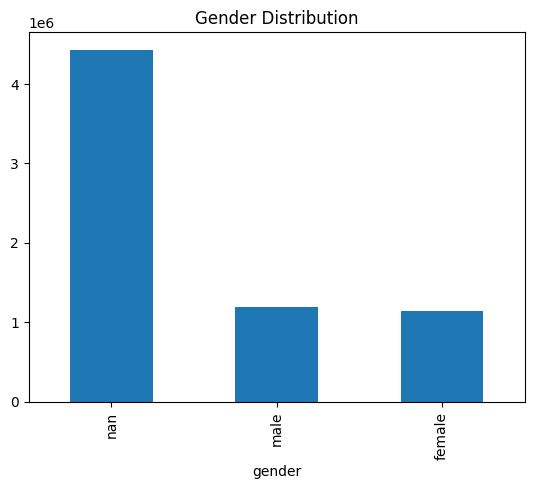

In [42]:
members_v3['gender'].value_counts(dropna=False).plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

Tỷ lệ rỗng của từng cột:
 msno                       0.000000
city                       0.000000
bd                         0.000000
gender                    65.433528
registered_via             0.000000
registration_init_time     0.000000
dtype: float64


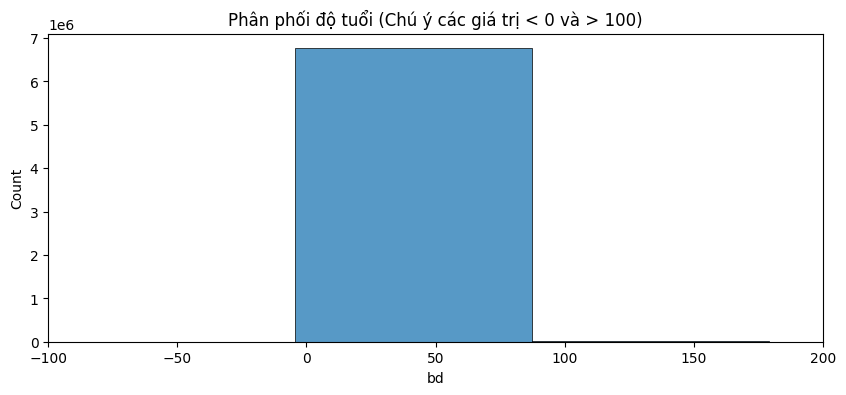

C:\Users\CUONG\AppData\Local\Temp\ipykernel_14192\2701089124.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=members_v3, x='gender', palette='pastel')


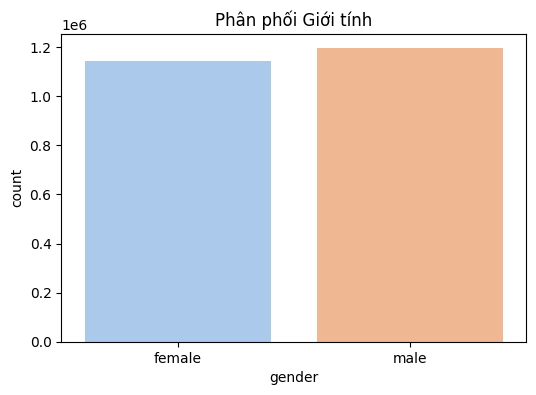

In [41]:

# Kiểm tra dữ liệu bị thiếu
print("Tỷ lệ rỗng của từng cột:\n", members_v3.isnull().mean() * 100)

# Vẽ biểu đồ phân phối tuổi (chỉ lấy khoảng tuổi từ -100 đến 200 để thấy rõ Outliers)
plt.figure(figsize=(10, 4))
sns.histplot(members_v3['bd'], bins=100, kde=False)
plt.xlim(-100, 200)
plt.title('Phân phối độ tuổi (Chú ý các giá trị < 0 và > 100)')
plt.show()

# Xem phân phối giới tính
plt.figure(figsize=(6, 4))
sns.countplot(data=members_v3, x='gender', palette='pastel')
plt.title('Phân phối Giới tính')
plt.show()

* Cột gender bị thiếu tới 65.43% (hơn 4.4 triệu dòng rỗng).

- Biểu đồ bd (Tuổi) và value_counts() cho thấy có đến 4.5 triệu người dùng có tuổi là 0. Ngoài ra còn có tuổi âm (-3152, -484) và tuổi siêu cao (573).

*Insight cốt lõi*
+ Giá trị 0 chiếm đại đa số (hơn 4.5 triệu dòng theo value_counts). 
+ Đây không phải là tuổi thật, mà là giá trị mặc định khi người dùng không chịu cung cấp tuổi hoặc hệ thống bị lỗi khi thu thập. Các giá trị âm hoặc lớn hơn 100 cũng xuất hiện.

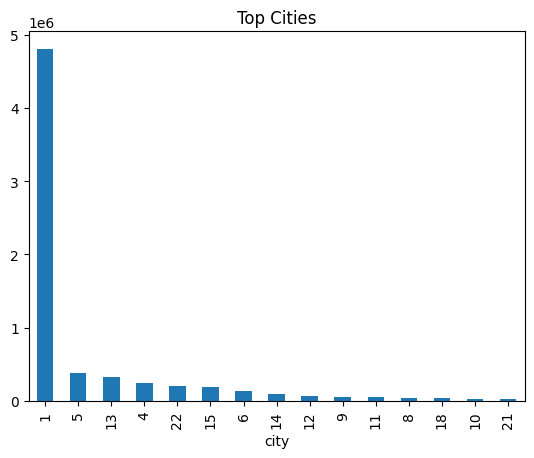

In [47]:
members_v3['city'].value_counts().head(15).plot(kind='bar')
plt.title('Top Cities')
plt.show()

- Nội dung hiển thị: Hiển thị các thành phố (được mã hóa thành số) và phương thức đăng ký phổ biến nhất.

*Đánh giá*

- Dữ liệu này khá sạch và có sự phân hóa rõ rệt. Mã thành phố 1 và 13 chiếm ưu thế. Phương thức đăng ký số 7 và 9 là phổ biến nhất.

-  Các cột này có thể giữ nguyên (là biến Categorical), có thể dùng Label Encoding hoặc One-Hot Encoding ở bước Modeling.

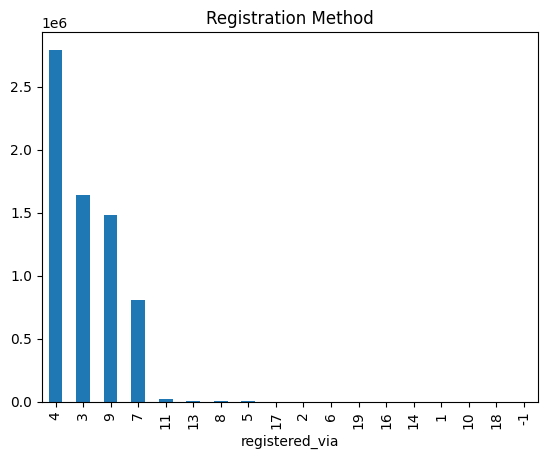

In [48]:
members_v3['registered_via'].value_counts().plot(kind='bar')
plt.title('Registration Method')
plt.show()

### transaction_v2

In [49]:
transactions_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   msno                    1431009 non-null  object
 1   payment_method_id       1431009 non-null  int64 
 2   payment_plan_days       1431009 non-null  int64 
 3   plan_list_price         1431009 non-null  int64 
 4   actual_amount_paid      1431009 non-null  int64 
 5   is_auto_renew           1431009 non-null  int64 
 6   transaction_date        1431009 non-null  int64 
 7   membership_expire_date  1431009 non-null  int64 
 8   is_cancel               1431009 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 98.3+ MB


In [50]:
transactions_v2.isnull().sum()

msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64

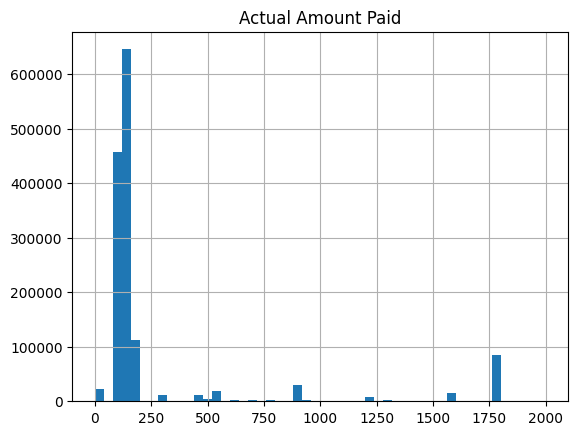

In [ ]:
transactions_v2['actual_amount_paid'].hist(bins=50)
plt.title('Actual Amount Paid')
plt.show()

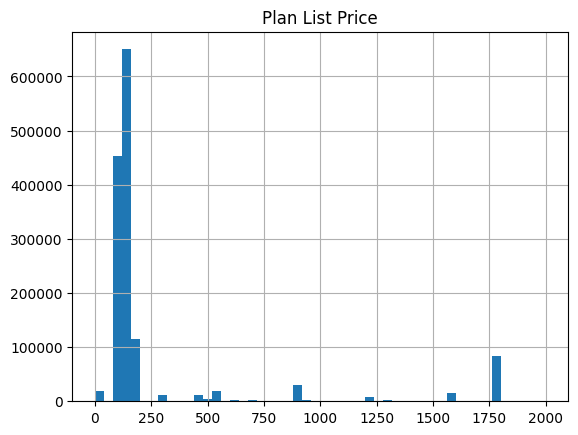

In [52]:
transactions_v2['plan_list_price'].hist(bins=50)
plt.title('Plan List Price')
plt.show()

- Nội dung hiển thị: Cả số tiền thực trả (actual_amount_paid) và giá niêm yết (plan_list_price) đều tập trung thành một vài cột nhọn (đỉnh cao nhất ở mức khoảng 149 NTD).

*Đánh giá:*

- Insight cốt lõi: Điều này hoàn toàn logic. Các gói cước có giá cố định (ví dụ gói chuẩn 149 NTD), nên dữ liệu sẽ không phân phối liên tục mà tụ lại ở các mức giá của các gói.

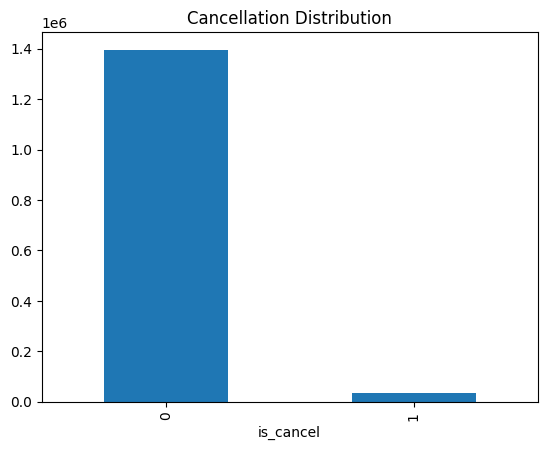

In [61]:
transactions_v2['is_cancel'].value_counts().plot(kind='bar')
plt.title('Cancellation Distribution')
plt.show()

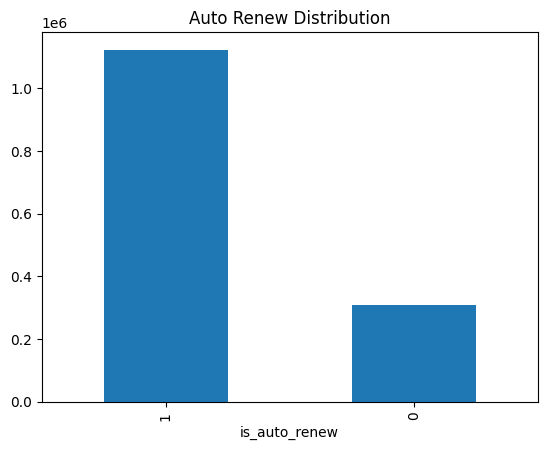

In [62]:
transactions_v2['is_auto_renew'].value_counts().plot(kind='bar')
plt.title('Auto Renew Distribution')
plt.show()

- is_cancel: Đa số là 0 (không hủy trong giao dịch này).

- is_auto_renew: Đa số là 1 (có bật tự động gia hạn) và 0 (không bật) cũng khá đáng kể.

*Đánh giá:*

- Đây là hai biến cực kỳ quan trọng cho dự đoán Churn. Người bật tự động gia hạn có xác suất ở lại cao hơn.

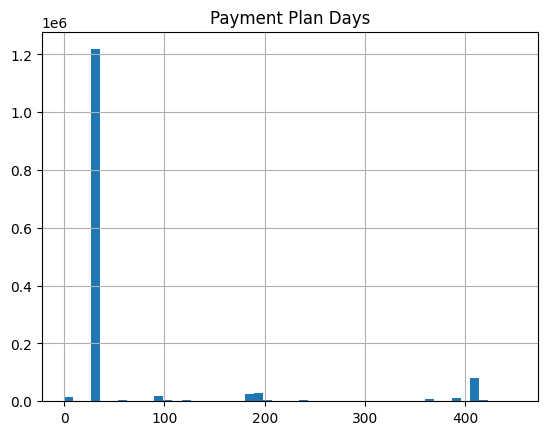

In [63]:
transactions_v2['payment_plan_days'].hist(bins=50)
plt.title('Payment Plan Days')
plt.show()

Đánh giá: Gói cước phổ biến nhất là gói 1 tháng (30 ngày).

### Transactions per user

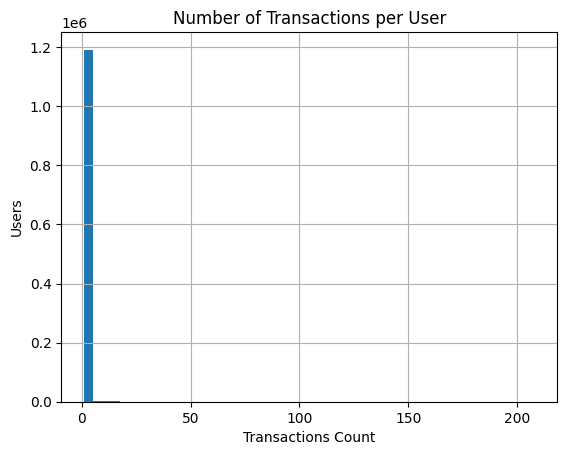

In [80]:
txn_per_user = transactions_v2.groupby('msno').size()

txn_per_user.hist(bins=50)
plt.title('Number of Transactions per User')
plt.xlabel('Transactions Count')
plt.ylabel('Users')
plt.show()

*Biểu đồ histogram cho thấy* : 
+ đa số user chỉ có rất ít transaction, thường 1–3 giao dịch.

+ Nhưng có đuôi dài 

*Điều này nói rằng:*
+ hành vi subscription giữa user rất không đồng đều
+ tồn tại nhóm power users / long-tenure users

*Đây là insight tốt*

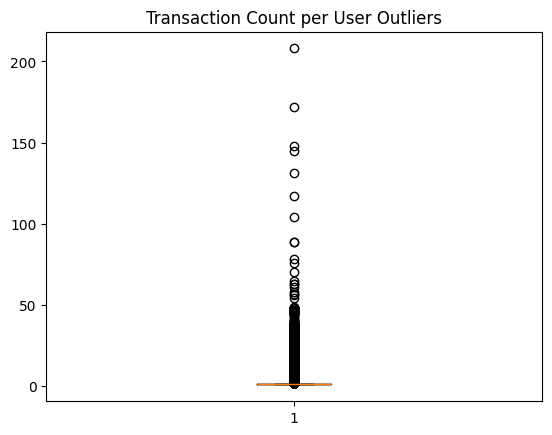

In [72]:
plt.boxplot(txn_per_user)
plt.title('Transaction Count per User Outliers')
plt.show()

- Phân bố số lượng giao dịch trên mỗi người dùng có độ lệch phải rất cao. Hầu hết người dùng chỉ có một vài giao dịch, trong khi một tỷ lệ nhỏ có số lượng giao dịch cực kỳ cao, cho thấy họ là người dùng lâu năm hoặc có mức độ tương tác cao. Những giá trị này được coi là tín hiệu hành vi chứ không phải là các giá trị ngoại lệ sai sót, do đó chúng được giữ lại để phục vụ cho việc xây dựng đặc trưng thay vì bị loại bỏ.


### user_v2

In [64]:
user_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 1.2+ GB


In [65]:
user_v2.isnull().sum()

msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64


Listening time

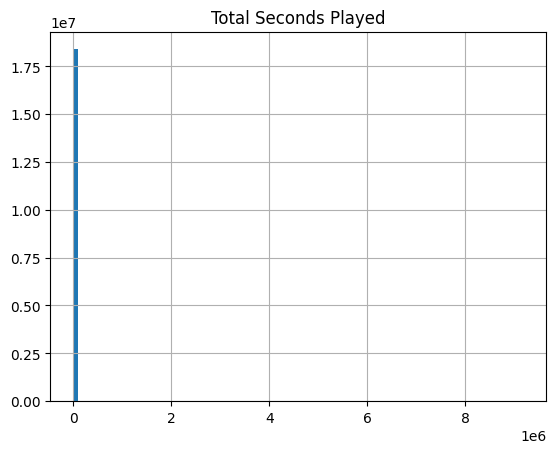

In [66]:
user_v2['total_secs'].hist(bins=100)
plt.title('Total Seconds Played')
plt.show()

- Nội dung hiển thị: Dữ liệu tập trung gần vạch 0 nhưng có một cái đuôi dài thượt kéo về bên phải (Right-skewed).

*Đánh giá:*

- Insight cốt lõi: Có một lượng nhỏ người dùng có tổng thời gian nghe nhạc trong ngày cực kỳ lớn, tạo ra phân phối lệch phải.

Unique songs

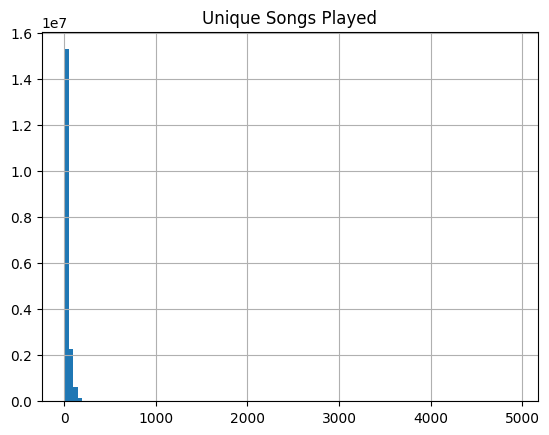

In [67]:
user_v2['num_unq'].hist(bins=100)
plt.title('Unique Songs Played')
plt.show()

Full play count

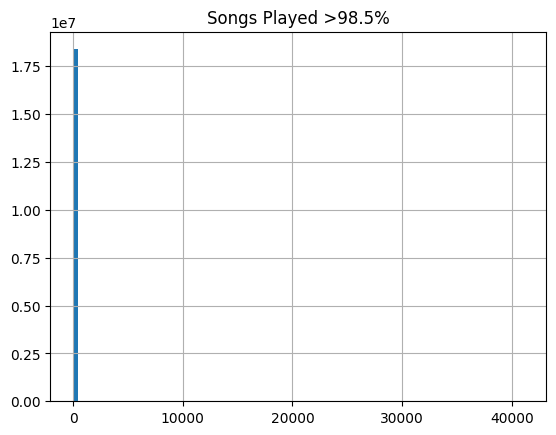

In [68]:
user_v2['num_100'].hist(bins=100)
plt.title('Songs Played >98.5%')
plt.show()

- Tương tự như total_secs, phân phối tập trung ở giá trị thấp và kéo đuôi dài về bên phải. Đa số nghe số lượng bài hát vừa phải, nhưng có người nghe hàng trăm bài mỗi ngày.

Outlier boxplot total_secs

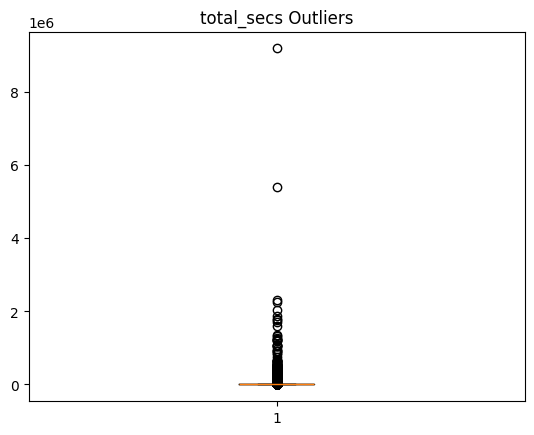

In [69]:
plt.boxplot(user_v2['total_secs'].dropna())
plt.title('total_secs Outliers')
plt.show()

- Nội dung hiển thị: Hộp (box) bị ép dẹp gí xuống sát trục X, bên trên là một dải dài các điểm đen chấm liên tục lên tới các mức giá trị khổng lồ.

- Đánh giá: Biểu đồ này đã làm cực kỳ tốt nhiệm vụ "tố cáo" các giá trị ngoại lai (Outliers). Một ngày có tối đa $24 \times 60 \times 60 = 86,400$ giây. Nếu có những điểm nằm xa tít phía trên (ví dụ vài trăm ngàn giây), đó là lỗi dữ liệu, bot, hoặc người dùng cắm máy chạy liên tục nhiều thiết bị.
- Cleaning: bắt buộc phải "cắt trần" (Cap/Clip) các giá trị này. Ví dụ, thiết lập bất kỳ giá trị total_secs nào lớn hơn 86,400 sẽ bị đưa về 86,400.

### Insight chi tiết

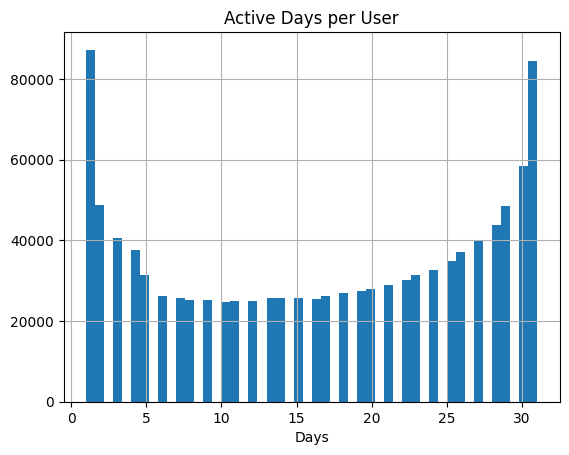

In [83]:
active_days = user_v2.groupby('msno')['date'].nunique()

active_days.hist(bins=50)
plt.title('Active Days per User')
plt.xlabel('Days')
plt.show()

- Cột trụ khổng lồ ở mốc ~30 ngày: Hơn 400,000 người dùng có số ngày hoạt động chạm đỉnh (hoặc gần đỉnh) của tháng.

- Cái bướu nhỏ ở mốc 0 - 5 ngày: Một lượng khá đông người dùng chỉ mở app vài lần rồi thôi.

- Khoảng giữa (10 - 20 ngày) trống vắng: Rất ít người dùng app ở mức độ "lưng chừng" (nửa tháng).

2. Insight Kinh doanh (Business Insight)
- Sản phẩm có độ dính (Stickiness) cực cao: Âm nhạc là một thói quen hàng ngày. Một khi khách hàng đã trả tiền cho KKBox, họ có xu hướng bật app lên nghe mỗi ngày. Khách hàng của nền tảng này cực kỳ trung thành.

- Dấu hiệu "Bỏ cuộc" sớm: Nhóm người dùng nằm ở mốc 1-5 ngày chính là những người dùng đang gặp vấn đề. Có thể họ không tìm thấy bài hát yêu thích, trải nghiệm app lỗi, hoặc họ đã chuyển sang dùng Spotify/Apple Music nhưng chưa đến hạn hủy gói.

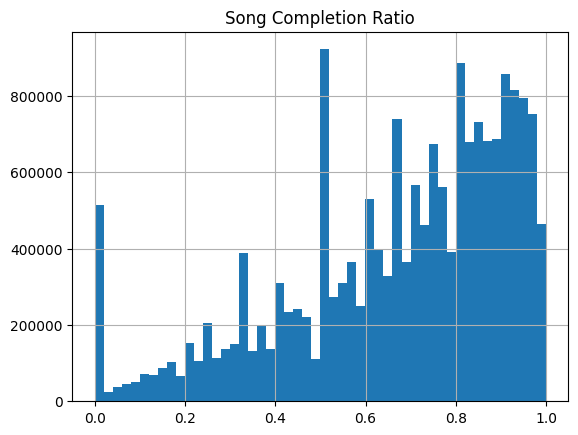

In [84]:
user_v2['completion_ratio'] = (
    user_v2['num_100'] /
    (
      user_v2['num_25']
      + user_v2['num_50']
      + user_v2['num_75']
      + user_v2['num_985']
      + user_v2['num_100']
      + 1
    )
)

user_v2['completion_ratio'].hist(bins=50)
plt.title('Song Completion Ratio')
plt.show()

- Hiện tượng: Bạn có thể thấy một cái đỉnh vút lên cao chót vót (mật độ lên tới hơn 4.0) nằm khít vào vạch 1.0.

- Insight: Đại đa số người dùng KKBox khi bật app lên là họ sẽ nghe trọn vẹn bài hát (từ 98.5% đến 100% thời lượng). Điều này chứng tỏ thói quen sử dụng phổ biến nhất là: bật một Playlist có sẵn, cắm tai nghe (hoặc nối loa Bluetooth) và để nhạc tự chạy hết bài này qua bài khác trong lúc làm việc/học tập.

- Đánh giá Churn: Nhóm này có mức độ hài lòng cao, xác suất rời bỏ rất thấp.

- Hiện tượng: Dữ liệu ở khoảng giữa cực kỳ thấp và phẳng.

- Insight: Rất hiếm khi có người nghe đúng 1 nửa bài hát rồi tắt. Hành vi con người rất rạch ròi: 1 là nghe hết, 2 là skip ngay từ những giây đầu tiên.